# Gait XGBoost — uso, treino e exportação para C/C++

Este notebook foi reorganizado para **duas tarefas**:

1. **Usar um modelo já salvo** em um CSV novo.  
2. **Treinar / atualizar o modelo** e salvar um novo artefato.

## Como usar
- Para quem **só quer usar o modelo**:
  1. Coloque `MODO = "usar_modelo_pronto"`.
  2. Ajuste `ARTIFACT_PATH` e `PLOT_FILE`.
  3. Rode o notebook de cima para baixo.

- Para quem **quer treinar novamente**:
  1. Coloque `MODO = "treinar_modelo"`.
  2. Ajuste `paths` e `HOLDOUT_TEST_IDS`.
  3. Rode o notebook inteiro.
  4. O notebook salva o artefato em `ARTIFACT_PATH`.

## Leitura rápida do problema
- **Classes 1–5** = fases reais da marcha.
- **Classe 0** = descarte / momento fora da marcha limpa (ex.: parada, pé virado).
- O modelo atual de referência é o **V5.3**, leve e já calibrado.

---

## Exportação para embarcado

No final do notebook existe uma seção opcional para gerar um arquivo `.h` no estilo:

```cpp
Eloquent::ML::Port::GaitXGB model;
int classe = model.predict(features);
```

Esse `.h` recebe um vetor de features `float x[]`. Portanto, para usar em microcontrolador, ainda é necessário calcular as features na mesma ordem do arquivo `*_features.json` exportado junto com o header.


In [ ]:
# Se precisar no Colab:
# !pip install -q xgboost

import os
import math
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from IPython.display import display
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
np.set_printoptions(suppress=True, precision=4)

## 1) Configuração principal

Aqui você escolhe:
- o modo de uso,
- o caminho do modelo salvo,
- o arquivo novo para previsão,
- e, se quiser treinar, os CSVs rotulados.

In [ ]:
# =========================
# MODO DE USO
# =========================
# "usar_modelo_pronto" -> carrega o artefato salvo e roda em um CSV novo
# "treinar_modelo"     -> treina / reavalia / salva um novo artefato
MODO = "usar_modelo_pronto"

# Monte o Drive se estiver no Colab
MONTAR_DRIVE = True

# =========================
# ARQUIVO PARA USO / INFERÊNCIA
# =========================
PLOT_FILE = "/content/drive/MyDrive/logs/alog_newF11.csv" #mudar isso aqui para o seu caminho amandinha
SALVAR_CSV_COM_PREDICAO = True
MOSTRAR_PLOTS = True
AVALIAR_SE_O_ARQUIVO_TIVER_ROTULO = True

# =========================
# CAMINHO DO MODELO SALVO
# =========================
ARTIFACT_PATH = "/content/drive/MyDrive/modelos/gait_xgb_v5_3_min.pkl" #mudar isso aqui para o seu caminho amandinha

# =========================
# DADOS DE TREINO (somente se MODO = 'treinar_modelo')
# =========================
paths = [
    "/content/drive/MyDrive/rotulados_testes/log_felix0_rot.csv", #mudar isso aqui para o seu caminho amandinha
    "/content/drive/MyDrive/rotulados_testes/log_felix1_rot.csv",
    "/content/drive/MyDrive/rotulados_testes/log_sah1_rot.csv",
    "/content/drive/MyDrive/rotulados_testes/log_cell1_rot.csv",
    "/content/drive/MyDrive/rotulados_testes/log_cell1.5_rot.csv",
    "/content/drive/MyDrive/rotulados_testes/log_sah2_rot.csv",
]

# Holdout final totalmente cego
HOLDOUT_TEST_IDS = [5]

# =========================
# HIPERPARÂMETROS / REGRAS DO PIPELINE
# =========================
WINDOW_SIZE = 30
STEP = 5
PURITY_THRESHOLD_KNOWN = 0.60
PURITY_THRESHOLD_UNKNOWN = 0.20

UNKNOWN_CLASS = 0
KNOWN_CLASSES = [1, 2, 3, 4, 5]
ALL_CLASSES = [0, 1, 2, 3, 4, 5]

# Classe 0 é descarte / reject
ENABLE_UNKNOWN_REJECT = True

# Rebalanceamento leve:
# - segura a classe 4
# - empurra a classe 2
# - mantém a classe 3 forte sem exagerar
MANUAL_CLASS_MULTIPLIERS = {
    1: 1.05,
    2: 1.45,
    3: 1.45,
    4: 0.60,
    5: 1.00,
}

OVERSAMPLE_MULTIPLIERS = {
    2: 2,
    3: 2,
}

FINAL_MODEL_PARAMS = {
    "n_estimators": 220,
    "learning_rate": 0.050,
    "max_depth": 4,
    "min_child_weight": 3,
    "gamma": 0.30,
    "subsample": 0.90,
    "colsample_bytree": 0.90,
    "reg_lambda": 2.8,
    "reg_alpha": 0.0,
}

TOEOFF_GUARD_PARAMS = {
    "n_estimators": 140,
    "learning_rate": 0.055,
    "max_depth": 3,
    "min_child_weight": 3,
    "gamma": 0.30,
    "subsample": 0.90,
    "colsample_bytree": 0.90,
    "reg_lambda": 2.0,
    "reg_alpha": 0.0,
}

REFINER23_PARAMS = {
    "n_estimators": 100,
    "learning_rate": 0.060,
    "max_depth": 3,
    "min_child_weight": 2,
    "gamma": 0.20,
    "subsample": 0.90,
    "colsample_bytree": 0.90,
    "reg_lambda": 2.0,
    "reg_alpha": 0.0,
}

PROB_BIAS_GRID = [
    {"bias2": 1.00, "bias3": 1.00, "bias4": 1.00},
    {"bias2": 1.10, "bias3": 1.00, "bias4": 0.80},
    {"bias2": 1.18, "bias3": 1.02, "bias4": 0.65},
    {"bias2": 1.25, "bias3": 1.05, "bias4": 0.55},
]

TOEOFF_ACCEPT_THRESHOLD_GRID = [0.80, 0.88, 0.92]
REFINE23_MARGIN_GRID = [None]
REJECT_THRESHOLD_GRID = [None, 0.45, 0.55]
POST_MODE_WINDOW_GRID = [1, 3]

if MONTAR_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception as e:
        print("Aviso: não foi possível montar o Google Drive automaticamente.")
        print(e)

print("Modo atual:", MODO)
print("Artefato:", ARTIFACT_PATH)
print("Arquivo para uso:", PLOT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modo atual: usar_modelo_pronto
Artefato: /content/drive/MyDrive/modelos/gait_xgb_v5_3_min.pkl
Arquivo para uso: /content/drive/MyDrive/logs/alog_newF11.csv


## 2) Pré-processamento dos CSVs

In [ ]:

map_fase = {
    "Desconhecida": 0,
    "Heel-strike": 1,
    "Foot-flat": 2,
    "Heel-off": 3,
    "Toe-off": 4,
    "Swing": 5,
}
rev_map_fase = {v: k for k, v in map_fase.items()}

LABEL_CANDIDATES = ["Fase", "fase", "label", "classe", "class", "target", "y"]

class SimpleKalman:
    def __init__(self, process_noise=0.01, sensor_noise=0.1, estimated_error=1.0, initial_value=0.0):
        self.Q = process_noise
        self.R = sensor_noise
        self.P = estimated_error
        self.x = initial_value

    def update(self, measurement):
        self.P = self.P + self.Q
        K = self.P / (self.P + self.R)
        self.x = self.x + K * (measurement - self.x)
        self.P = (1 - K) * self.P
        return self.x

def resolve_label_column(df_in):
    for col in LABEL_CANDIDATES:
        if col in df_in.columns:
            return col
    return None

def standardize_label_column(df_in, require_label=True):
    df_out = df_in.copy()
    label_col = resolve_label_column(df_out)

    if label_col is None:
        if require_label:
            raise KeyError(
                "Nenhuma coluna de rótulo encontrada. "
                f"Procurei por {LABEL_CANDIDATES}, mas encontrei: {list(df_out.columns)}"
            )
        df_out["Fase"] = UNKNOWN_CLASS
        df_out["tem_rotulo_real"] = False
        return df_out

    if label_col != "Fase":
        df_out["Fase"] = df_out[label_col]

    if df_out["Fase"].dtype == object:
        df_out["Fase"] = df_out["Fase"].replace(map_fase)

    df_out["Fase"] = pd.to_numeric(df_out["Fase"], errors="coerce")
    if require_label and df_out["Fase"].isna().any():
        bad_examples = df_in.loc[df_out["Fase"].isna(), label_col].astype(str).unique().tolist()[:10]
        raise ValueError(
            "A coluna de rótulo foi encontrada, mas há valores que não puderam ser convertidos para inteiros. "
            f"Exemplos problemáticos: {bad_examples}"
        )

    df_out["Fase"] = df_out["Fase"].fillna(UNKNOWN_CLASS).astype(int)
    df_out["tem_rotulo_real"] = True
    return df_out

def ensure_required_sensor_columns(dfi):
    required = ["ax", "ay", "az", "gx", "gy", "gz"]
    missing = [c for c in required if c not in dfi.columns]
    if missing:
        raise KeyError(f"Colunas obrigatórias ausentes no CSV: {missing}")

def add_temporal_columns(dfi):
    if "timestamp" in dfi.columns:
        t0 = dfi["timestamp"].iloc[0]
        span = float(dfi["timestamp"].iloc[-1] - t0) if len(dfi) > 1 else 0.0
        divisor = 1000.0 if span > 100 else 1.0
        dfi["tempo_s"] = (dfi["timestamp"] - t0) / divisor
    else:
        dfi["tempo_s"] = np.arange(len(dfi), dtype=float)
    return dfi

def add_orientation_and_norms(dfi):
    kalman_roll = SimpleKalman()
    kalman_pitch = SimpleKalman()

    roll_list, pitch_list = [], []
    for _, row in dfi.iterrows():
        ax, ay, az = float(row["ax"]), float(row["ay"]), float(row["az"])
        raw_roll = math.degrees(math.atan2(ay, az))
        raw_pitch = math.degrees(math.atan2(-ax, math.sqrt(ay**2 + az**2)))
        roll_list.append(kalman_roll.update(raw_roll))
        pitch_list.append(kalman_pitch.update(raw_pitch))

    dfi["roll"] = roll_list
    dfi["pitch_k"] = pitch_list
    dfi["acc_norm"] = np.sqrt(dfi["ax"]**2 + dfi["ay"]**2 + dfi["az"]**2)
    dfi["gyro_norm"] = np.sqrt(dfi["gx"]**2 + dfi["gy"]**2 + dfi["gz"]**2)
    return dfi

def add_derivative_columns(dfi):
    base_diff_cols = ["ax", "ay", "az", "gx", "gy", "gz", "roll", "pitch_k", "acc_norm", "gyro_norm"]
    for col in base_diff_cols:
        dfi[f"d_{col}"] = dfi[col].diff().fillna(0.0)
        dfi[f"dd_{col}"] = dfi[f"d_{col}"].diff().fillna(0.0)

    dfi["jerk_acc"] = dfi["acc_norm"].diff().fillna(0.0)
    dfi["jerk_gyro"] = dfi["gyro_norm"].diff().fillna(0.0)
    return dfi

def preprocess_single_file(path, arquivo_id, require_label=True):
    dfi = pd.read_csv(path).copy()
    dfi = dfi.drop(columns=["classe_prevista", "classe_prevista_raw", "confianca_prevista"], errors="ignore")
    dfi["arquivo_id"] = int(arquivo_id)
    dfi["arquivo_nome"] = os.path.basename(path)

    ensure_required_sensor_columns(dfi)
    dfi = standardize_label_column(dfi, require_label=require_label)
    dfi = add_temporal_columns(dfi)
    dfi = add_orientation_and_norms(dfi)
    dfi = add_derivative_columns(dfi)
    return dfi

## 3) Features por janela

In [ ]:

AXES = [
    "ax", "ay", "az",
    "gx", "gy", "gz",
    "roll", "pitch_k",
    "acc_norm", "gyro_norm",
    "d_ax", "d_ay", "d_az",
    "d_gx", "d_gy", "d_gz",
    "dd_ax", "dd_ay", "dd_az",
    "dd_gx", "dd_gy", "dd_gz",
    "jerk_acc", "jerk_gyro",
]

PAIRWISE_CORR_COLS = [
    ("ax", "ay"), ("ax", "az"), ("ay", "az"),
    ("gx", "gy"), ("gx", "gz"), ("gy", "gz"),
    ("acc_norm", "gyro_norm"),
    ("roll", "pitch_k"),
]

HALF_COMPARISON_AXES = ["acc_norm", "gyro_norm", "roll", "pitch_k", "d_ax", "d_gz"]
TRANSITION_FOCUS_AXES = ["gx", "gz", "pitch_k", "roll"]

def safe_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if len(a) < 2 or np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])

def spectral_features(signal):
    signal = np.asarray(signal, dtype=float)
    if len(signal) == 0:
        return [0.0, 0.0, 0.0]

    centered = signal - signal.mean()
    spec = np.abs(np.fft.rfft(centered))
    if len(spec) <= 1:
        return [0.0, 0.0, 0.0]

    spec = spec[1:]
    total = float(spec.sum())
    if total <= 1e-12:
        return [0.0, 0.0, 0.0]

    dom_bin = float(np.argmax(spec) + 1)
    dom_ratio = float(spec.max() / (total + 1e-12))
    p = spec / (total + 1e-12)
    spectral_entropy = float(-(p * np.log(p + 1e-12)).sum() / np.log(len(p) + 1e-12))
    return [dom_bin, dom_ratio, spectral_entropy]

def zero_cross_count(signal):
    signal = np.asarray(signal, dtype=float)
    if len(signal) < 2:
        return 0.0
    signs = np.sign(signal)
    return float(np.sum(signs[1:] * signs[:-1] < 0))

def peak_position_ratio(signal, absolute=False):
    signal = np.asarray(signal, dtype=float)
    if len(signal) == 0:
        return 0.0
    idx = int(np.argmax(np.abs(signal))) if absolute else int(np.argmax(signal))
    return float(idx / max(len(signal) - 1, 1))

def time_since_last_peak_ratio(signal):
    signal = np.asarray(signal, dtype=float)
    n = len(signal)
    if n < 3:
        return 0.0
    peak_idxs = np.where((signal[1:-1] > signal[:-2]) & (signal[1:-1] >= signal[2:]))[0] + 1
    if len(peak_idxs) == 0:
        return 1.0
    return float((n - 1 - peak_idxs[-1]) / max(n - 1, 1))

def center_slope(signal, radius=2):
    signal = np.asarray(signal, dtype=float)
    n = len(signal)
    if n < 2:
        return 0.0
    c = n // 2
    left = max(0, c - radius)
    right = min(n - 1, c + radius)
    if right == left:
        return 0.0
    return float((signal[right] - signal[left]) / max(right - left, 1))

def local_amplitude(signal, radius=3):
    signal = np.asarray(signal, dtype=float)
    n = len(signal)
    c = n // 2
    sl = signal[max(0, c - radius): min(n, c + radius + 1)]
    if len(sl) == 0:
        return 0.0
    return float(np.max(sl) - np.min(sl))

def half_ratio(signal):
    signal = np.asarray(signal, dtype=float)
    n = len(signal)
    half = n // 2
    first = signal[:half]
    second = signal[half:]
    if len(first) == 0 or len(second) == 0:
        return 0.0
    return float(second.mean() / (np.abs(first.mean()) + 1e-6))

def extrair_features_signal(signal):
    signal = np.asarray(signal, dtype=float)
    n = len(signal)
    diff = np.diff(signal) if n > 1 else np.array([0.0])
    center = n // 2

    amp = float(signal.max() - signal.min())
    center_mean = float(signal[max(0, center - 2): min(n, center + 3)].mean())

    feats = [
        float(signal.mean()),
        float(signal.std(ddof=0)),
        float(np.median(signal)),
        float(signal.min()),
        float(signal.max()),
        float(np.percentile(signal, 10)),
        float(np.percentile(signal, 25)),
        float(np.percentile(signal, 75)),
        float(np.percentile(signal, 90)),
        float(signal[0]),
        float(signal[-1]),
        float(signal[-1] - signal[0]),
        float(center_mean),
        float(np.mean(np.abs(diff))),
        float(np.std(diff, ddof=0)),
        float(np.sqrt(np.mean(signal**2))),
        float(np.mean(signal**2)),
        amp,
        float(np.argmax(np.abs(signal)) / max(n - 1, 1)),
        float(np.argmin(signal) / max(n - 1, 1)),
        zero_cross_count(signal),
        float(diff[max(0, len(diff)//2 - 1): min(len(diff), len(diff)//2 + 2)].mean()),
    ]
    feats.extend(spectral_features(signal))
    return feats

def build_window_feature_vector(window):
    features = []

    for axis in AXES:
        sig = window[axis].to_numpy(dtype=float)
        features.extend(extrair_features_signal(sig))

    for a, b in PAIRWISE_CORR_COLS:
        features.append(safe_corr(window[a].to_numpy(dtype=float), window[b].to_numpy(dtype=float)))

    half = len(window) // 2
    for axis in HALF_COMPARISON_AXES:
        sig = window[axis].to_numpy(dtype=float)
        first_half = sig[:half]
        second_half = sig[half:]
        features.append(float(second_half.mean() - first_half.mean()))
        features.append(float(second_half.std(ddof=0) - first_half.std(ddof=0)))
        denom = np.abs(first_half.mean()) + 1e-6
        features.append(float(second_half.mean() / denom))

    for axis in TRANSITION_FOCUS_AXES:
        sig = window[axis].to_numpy(dtype=float)
        features.append(center_slope(sig))
        features.append(peak_position_ratio(sig, absolute=(axis in ["gx", "gz"])))
        features.append(time_since_last_peak_ratio(sig))
        features.append(half_ratio(sig))

    features.append(local_amplitude(window["pitch_k"].to_numpy(dtype=float)))
    features.append(local_amplitude(window["roll"].to_numpy(dtype=float)))

    gz_sig = window["gz"].to_numpy(dtype=float)
    features.append(peak_position_ratio(gz_sig, absolute=True))
    features.append(center_slope(gz_sig))
    features.append(local_amplitude(gz_sig))

    return features

def create_windows(df_in, window_size, step, include_unknown=False,
                   purity_threshold_known=0.60, purity_threshold_unknown=0.20):
    segments, labels_original, meta = [], [], []

    for arquivo_id, dfg in df_in.groupby("arquivo_id", sort=False):
        dfg = dfg.reset_index(drop=True)
        arquivo_nome = dfg["arquivo_nome"].iloc[0]

        for i in range(0, len(dfg) - window_size + 1, step):
            window = dfg.iloc[i:i + window_size]
            center_idx = i + (window_size // 2)
            center_label = int(dfg.iloc[center_idx]["Fase"])
            purity = float((window["Fase"].to_numpy() == center_label).mean())

            if center_label == UNKNOWN_CLASS:
                if not include_unknown:
                    continue
                if purity < purity_threshold_unknown:
                    continue
            else:
                if center_label not in KNOWN_CLASSES:
                    continue
                if purity < purity_threshold_known:
                    continue

            features = build_window_feature_vector(window)

            segments.append(features)
            labels_original.append(center_label)
            meta.append({
                "arquivo_id": int(arquivo_id),
                "arquivo_nome": arquivo_nome,
                "start": int(i),
                "end": int(i + window_size - 1),
                "center": int(center_idx),
                "label_original": int(center_label),
                "purity": float(purity),
            })

    X = np.asarray(segments, dtype=float)
    y_original = np.asarray(labels_original, dtype=int)
    meta = pd.DataFrame(meta)
    return X, y_original, meta

print("Número de sinais base usados:", len(AXES))


Número de sinais base usados: 24


## 4) Modelo, rebalanceamento e pós-processamento leve

In [ ]:
def compute_sample_weights_known(y_known_original):
    classes = np.array(KNOWN_CLASSES)
    base_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_known_original)
    weights = {c: w for c, w in zip(classes, base_weights)}

    for classe_original, mult in MANUAL_CLASS_MULTIPLIERS.items():
        if classe_original in weights:
            weights[classe_original] *= float(mult)

    sample_weight = np.array([weights[c] for c in y_known_original], dtype=float)
    return sample_weight, weights

def oversample_known_windows(X, y_original, meta, multipliers):
    X_parts = [X]
    y_parts = [y_original]
    meta_parts = [meta.copy()]

    for classe_original, mult in multipliers.items():
        if mult is None or mult <= 1:
            continue
        idx = np.where(y_original == classe_original)[0]
        if len(idx) == 0:
            continue
        reps = int(mult) - 1
        for r in range(reps):
            X_parts.append(X[idx].copy())
            y_parts.append(y_original[idx].copy())
            meta_dup = meta.iloc[idx].copy()
            meta_dup["oversample_copy"] = r + 1
            meta_parts.append(meta_dup)

    X_out = np.vstack(X_parts)
    y_out = np.concatenate(y_parts)
    meta_out = pd.concat(meta_parts, ignore_index=True)
    return X_out, y_out, meta_out

def make_internal_eval_split_known(X_known, y_known_original, meta_known=None, test_size=0.18, random_state=777):
    idx = np.arange(len(y_known_original))
    train_idx, eval_idx = train_test_split(
        idx,
        test_size=test_size,
        random_state=random_state,
        stratify=y_known_original,
    )

    X_tr = X_known[train_idx]
    y_tr = y_known_original[train_idx]
    X_ev = X_known[eval_idx]
    y_ev = y_known_original[eval_idx]

    if meta_known is not None:
        meta_tr = meta_known.iloc[train_idx].reset_index(drop=True)
        meta_ev = meta_known.iloc[eval_idx].reset_index(drop=True)
        return X_tr, y_tr, meta_tr, X_ev, y_ev, meta_ev

    return X_tr, y_tr, X_ev, y_ev

def build_multiclass_xgb_classifier(num_class, params=None, random_state=56):
    params = FINAL_MODEL_PARAMS if params is None else params
    return xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=num_class,
        tree_method="hist",
        eval_metric=["mlogloss", "merror"],
        early_stopping_rounds=35,
        random_state=random_state,
        **params
    )

def build_binary_xgb_classifier(params, random_state=56):
    return xgb.XGBClassifier(
        objective="binary:logistic",
        tree_method="hist",
        eval_metric=["logloss", "error"],
        early_stopping_rounds=25,
        random_state=random_state,
        **params
    )

def mode_filter_sequence(seq, window=3):
    seq = np.asarray(seq, dtype=int)
    if window <= 1:
        return seq.copy()
    s = pd.Series(seq)
    filtered = s.rolling(window, center=True, min_periods=1).apply(
        lambda x: pd.Series(x.astype(int)).mode().iloc[0], raw=False
    )
    return filtered.round().astype(int).to_numpy()

def train_toeoff_guard(X_train_known, y_train_known_original, random_state=56):
    y_bin = (y_train_known_original == 4).astype(int)
    if y_bin.sum() < 10:
        return None

    X_tr, X_ev, y_tr, y_ev = train_test_split(
        X_train_known,
        y_bin,
        test_size=0.18,
        random_state=random_state,
        stratify=y_bin,
    )

    pos = float(y_tr.sum())
    neg = float(len(y_tr) - y_tr.sum())
    scale_pos_weight = max(neg / max(pos, 1.0), 1.0)

    params = dict(TOEOFF_GUARD_PARAMS)
    params["scale_pos_weight"] = scale_pos_weight

    model = build_binary_xgb_classifier(params=params, random_state=random_state)
    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_ev, y_ev)],
        verbose=False,
    )
    return model

def train_refiner23(X_train_known, y_train_known_original, random_state=56):
    return None

def apply_reject_threshold(pred_original, prob_known, reject_threshold=None):
    pred_final = np.asarray(pred_original, dtype=int).copy()
    max_conf = np.max(prob_known, axis=1)
    if (reject_threshold is not None) and ENABLE_UNKNOWN_REJECT:
        pred_final[max_conf < float(reject_threshold)] = UNKNOWN_CLASS
    return pred_final, max_conf

def apply_probability_bias(prob_known, bias_cfg=None):
    prob = np.asarray(prob_known, dtype=float).copy()
    if bias_cfg is None:
        return prob

    idx2 = KNOWN_CLASSES.index(2)
    idx3 = KNOWN_CLASSES.index(3)
    idx4 = KNOWN_CLASSES.index(4)

    prob[:, idx2] *= float(bias_cfg.get("bias2", 1.0))
    prob[:, idx3] *= float(bias_cfg.get("bias3", 1.0))
    prob[:, idx4] *= float(bias_cfg.get("bias4", 1.0))

    row_sum = prob.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1.0
    prob /= row_sum
    return prob

def best_non4_label_from_prob(prob_row):
    idx4 = KNOWN_CLASSES.index(4)
    tmp = np.asarray(prob_row, dtype=float).copy()
    tmp[idx4] = -1.0
    return KNOWN_CLASSES[int(np.argmax(tmp))]

def apply_light_refiners(X, prob_known, pred_original, toeoff_guard_model=None, refiner23_model=None,
                         toeoff_accept_threshold=0.88, refine23_margin=None):
    pred = np.asarray(pred_original, dtype=int).copy()
    prob_known = np.asarray(prob_known, dtype=float)

    # Toe-off guard mais conservador:
    # aceita classe 4 apenas quando o multiclasses e o binário concordam bem
    if toeoff_guard_model is not None:
        mask4 = pred == 4
        if mask4.any():
            p4_guard = toeoff_guard_model.predict_proba(X[mask4])[:, 1]
            p4_main = prob_known[mask4, KNOWN_CLASSES.index(4)]

            tmp = prob_known[mask4].copy()
            tmp[:, KNOWN_CLASSES.index(4)] = -1.0
            next_best = tmp.max(axis=1)
            margin4 = p4_main - next_best

            veto = (
                (p4_guard < float(toeoff_accept_threshold)) |
                (p4_main < float(toeoff_accept_threshold)) |
                (margin4 < 0.05)
            )
            if veto.any():
                idx_mask4 = np.where(mask4)[0]
                for local_i, global_i in enumerate(idx_mask4):
                    if veto[local_i]:
                        pred[global_i] = best_non4_label_from_prob(prob_known[global_i])

    return pred


## 5) Métricas e utilidades de avaliação

In [ ]:
def summarize_metrics(y_true_original, y_pred_original, labels):
    return {
        "accuracy": accuracy_score(y_true_original, y_pred_original),
        "balanced_acc": balanced_accuracy_score(y_true_original, y_pred_original),
        "precision_weighted": precision_score(y_true_original, y_pred_original, average="weighted", zero_division=0, labels=labels),
        "recall_weighted": recall_score(y_true_original, y_pred_original, average="weighted", zero_division=0, labels=labels),
        "f1_weighted": f1_score(y_true_original, y_pred_original, average="weighted", zero_division=0, labels=labels),
        "f1_macro": f1_score(y_true_original, y_pred_original, average="macro", zero_division=0, labels=labels),
    }

def known_only_view(y_true_original, y_pred_original):
    mask = np.isin(y_true_original, KNOWN_CLASSES)
    return y_true_original[mask], y_pred_original[mask]

def build_class_metric_maps(y_true_known, y_pred_known):
    prec = precision_score(y_true_known, y_pred_known, labels=KNOWN_CLASSES, average=None, zero_division=0)
    rec = recall_score(y_true_known, y_pred_known, labels=KNOWN_CLASSES, average=None, zero_division=0)
    f1v = f1_score(y_true_known, y_pred_known, labels=KNOWN_CLASSES, average=None, zero_division=0)
    return (
        {c: float(v) for c, v in zip(KNOWN_CLASSES, prec)},
        {c: float(v) for c, v in zip(KNOWN_CLASSES, rec)},
        {c: float(v) for c, v in zip(KNOWN_CLASSES, f1v)},
    )

def score_candidate(y_true_original, y_pred_original):
    yk_true, yk_pred = known_only_view(y_true_original, y_pred_original)

    known_metrics = summarize_metrics(yk_true, yk_pred, labels=KNOWN_CLASSES)
    full_metrics = summarize_metrics(y_true_original, y_pred_original, labels=ALL_CLASSES)
    precision_map, recall_map, f1_map = build_class_metric_maps(yk_true, yk_pred)

    score = (
        0.28 * known_metrics["f1_macro"] +
        0.18 * known_metrics["balanced_acc"] +
        0.14 * known_metrics["f1_weighted"] +
        0.16 * recall_map.get(2, 0.0) +
        0.10 * recall_map.get(3, 0.0) +
        0.10 * precision_map.get(4, 0.0) +
        0.04 * recall_map.get(4, 0.0)
    )

    return score, known_metrics, full_metrics, precision_map, recall_map, f1_map

def print_metrics_block(title, metrics_dict):
    print(title)
    for k, v in metrics_dict.items():
        print(f"  {k}: {v:.4f}")

def plot_confusion_original(y_true_original, y_pred_original, title, labels):
    class_names = [f"{c} - {rev_map_fase[c]}" for c in labels]
    cm_abs = confusion_matrix(y_true_original, y_pred_original, labels=labels)
    cm_pct = cm_abs.astype(float) / np.maximum(cm_abs.sum(axis=1, keepdims=True), 1)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_abs, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
    plt.title(title + " | Matriz absoluta")
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_pct, annot=True, fmt=".1%", xticklabels=class_names, yticklabels=class_names)
    plt.title(title + " | Matriz normalizada")
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.show()

def evaluate_predictions(y_true_original, y_pred_original, title="", show_report=True):
    score, known_metrics, full_metrics, precision_map, recall_map, f1_map = score_candidate(y_true_original, y_pred_original)

    if show_report:
        print("\n" + "=" * 95)
        print(title)
        print_metrics_block("Known-only (classes 1–5)", known_metrics)
        print_metrics_block("Full (0–5)", full_metrics)
        print("Precision por classe conhecida:", {k: round(v, 4) for k, v in precision_map.items()})
        print("Recall por classe conhecida:", {k: round(v, 4) for k, v in recall_map.items()})
        print("F1 por classe conhecida:", {k: round(v, 4) for k, v in f1_map.items()})
        print(f"Score composto: {score:.4f}")

        print("\nRelatório full (0–5):")
        print(classification_report(
            y_true_original, y_pred_original,
            labels=ALL_CLASSES,
            target_names=[f"{c} - {rev_map_fase[c]}" for c in ALL_CLASSES],
            zero_division=0
        ))

    return {
        "score": score,
        "known_metrics": known_metrics,
        "full_metrics": full_metrics,
        "precision_map": precision_map,
        "recall_map": recall_map,
        "f1_map": f1_map,
    }


## 6) Funções de treino e salvamento do artefato

In [ ]:
def load_training_dataframe(paths):
    dfs = []
    for idx, path in enumerate(paths):
        dfs.append(preprocess_single_file(path, idx, require_label=True))
    df_all = pd.concat(dfs, ignore_index=True)
    return df_all

def train_pipeline(paths, holdout_test_ids, artifact_path=None, save_artifact=True):
    df = load_training_dataframe(paths)

    print("Arquivos carregados:", df["arquivo_nome"].nunique())
    print(df[["arquivo_id", "arquivo_nome"]].drop_duplicates().to_string(index=False))
    print("\nDistribuição geral de classes:")
    print(df["Fase"].value_counts().sort_index())

    all_ids = list(range(len(paths)))
    dev_ids = [i for i in all_ids if i not in holdout_test_ids]

    print("\nArquivos DEV (LOSO CV):", dev_ids)
    print("Arquivos HOLDOUT TEST:", holdout_test_ids)

    cv_rows = []

    for val_id in dev_ids:
        train_ids = [i for i in dev_ids if i != val_id]

        df_train_fold = df[df["arquivo_id"].isin(train_ids)].copy()
        df_val_fold = df[df["arquivo_id"] == val_id].copy()

        X_train_base, y_train_base_orig, meta_train_base = create_windows(
            df_train_fold, WINDOW_SIZE, STEP,
            include_unknown=False,
            purity_threshold_known=PURITY_THRESHOLD_KNOWN,
            purity_threshold_unknown=PURITY_THRESHOLD_UNKNOWN,
        )

        X_val, y_val_orig, meta_val = create_windows(
            df_val_fold, WINDOW_SIZE, STEP,
            include_unknown=True,
            purity_threshold_known=PURITY_THRESHOLD_KNOWN,
            purity_threshold_unknown=PURITY_THRESHOLD_UNKNOWN,
        )

        X_train_main, y_train_main_orig, meta_train_main = oversample_known_windows(
            X_train_base, y_train_base_orig, meta_train_base, OVERSAMPLE_MULTIPLIERS
        )

        le = LabelEncoder()
        le.fit(KNOWN_CLASSES)
        y_train_main_enc = le.transform(y_train_main_orig)

        sample_weight_train, weights_map = compute_sample_weights_known(y_train_main_orig)

        mask_val_known = np.isin(y_val_orig, KNOWN_CLASSES)
        X_val_known = X_val[mask_val_known]
        y_val_known_enc = le.transform(y_val_orig[mask_val_known])

        model = build_multiclass_xgb_classifier(len(KNOWN_CLASSES), FINAL_MODEL_PARAMS, random_state=56 + int(val_id))
        model.fit(
            X_train_main,
            y_train_main_enc,
            sample_weight=sample_weight_train,
            eval_set=[(X_val_known, y_val_known_enc)],
            verbose=False,
        )

        toeoff_guard = train_toeoff_guard(X_train_base, y_train_base_orig, random_state=1000 + int(val_id))

        print("\n" + "#" * 100)
        print(f"Fold LOSO | val arquivo_id={val_id} | arquivo={df_val_fold['arquivo_nome'].iloc[0]}")
        print("Treino:", df_train_fold["arquivo_nome"].unique())
        print("Validação:", df_val_fold["arquivo_nome"].unique())
        print("Pesos:", {int(k): round(float(v), 4) for k, v in weights_map.items()})

        # RAW puro
        prob_val_raw = model.predict_proba(X_val)
        pred_raw_known_original = le.inverse_transform(np.argmax(prob_val_raw, axis=1))
        pred_raw_original, _ = apply_reject_threshold(pred_raw_known_original, prob_val_raw, reject_threshold=None)
        raw_eval = evaluate_predictions(y_val_orig, pred_raw_original, title="", show_report=False)

        cv_rows.append({
            "fold_val_id": val_id,
            "arquivo_val": df_val_fold["arquivo_nome"].iloc[0],
            "variant": "raw",
            "bias2": 1.0,
            "bias3": 1.0,
            "bias4": 1.0,
            "toeoff_accept_threshold": np.nan,
            "reject_threshold": np.nan,
            "post_mode_window": 1,
            "score": raw_eval["score"],
            **{f"known_{k}": v for k, v in raw_eval["known_metrics"].items()},
            "precision_cls4": raw_eval["precision_map"].get(4, 0.0),
            "recall_cls2": raw_eval["recall_map"].get(2, 0.0),
            "recall_cls3": raw_eval["recall_map"].get(3, 0.0),
            "recall_cls4": raw_eval["recall_map"].get(4, 0.0),
            "f1_cls4": raw_eval["f1_map"].get(4, 0.0),
        })

        # Calibrado leve
        for bias_cfg in PROB_BIAS_GRID:
            prob_val = apply_probability_bias(prob_val_raw, bias_cfg)
            pred_known_original = le.inverse_transform(np.argmax(prob_val, axis=1))

            for toe_thr in TOEOFF_ACCEPT_THRESHOLD_GRID:
                pred_calibrated = apply_light_refiners(
                    X=X_val,
                    prob_known=prob_val,
                    pred_original=pred_known_original,
                    toeoff_guard_model=toeoff_guard,
                    refiner23_model=None,
                    toeoff_accept_threshold=toe_thr,
                    refine23_margin=None,
                )

                for reject_thr in REJECT_THRESHOLD_GRID:
                    pred_post, _ = apply_reject_threshold(pred_calibrated, prob_val, reject_threshold=reject_thr)

                    for mode_w in POST_MODE_WINDOW_GRID:
                        pred_final = mode_filter_sequence(pred_post, window=int(mode_w))
                        eval_res = evaluate_predictions(y_val_orig, pred_final, title="", show_report=False)

                        cv_rows.append({
                            "fold_val_id": val_id,
                            "arquivo_val": df_val_fold["arquivo_nome"].iloc[0],
                            "variant": "calibrated",
                            "bias2": float(bias_cfg["bias2"]),
                            "bias3": float(bias_cfg["bias3"]),
                            "bias4": float(bias_cfg["bias4"]),
                            "toeoff_accept_threshold": toe_thr,
                            "reject_threshold": reject_thr,
                            "post_mode_window": int(mode_w),
                            "score": eval_res["score"],
                            **{f"known_{k}": v for k, v in eval_res["known_metrics"].items()},
                            "precision_cls4": eval_res["precision_map"].get(4, 0.0),
                            "recall_cls2": eval_res["recall_map"].get(2, 0.0),
                            "recall_cls3": eval_res["recall_map"].get(3, 0.0),
                            "recall_cls4": eval_res["recall_map"].get(4, 0.0),
                            "f1_cls4": eval_res["f1_map"].get(4, 0.0),
                        })

    cv_results = pd.DataFrame(cv_rows)
    print("\nResultados brutos do LOSO:")
    display(cv_results.head())

    agg_cols = [
        "variant", "bias2", "bias3", "bias4",
        "toeoff_accept_threshold", "reject_threshold", "post_mode_window"
    ]

    config_rank = (
        cv_results
        .groupby(agg_cols, dropna=False)
        .agg(
            mean_score=("score", "mean"),
            std_score=("score", "std"),
            mean_known_f1_macro=("known_f1_macro", "mean"),
            mean_known_bal_acc=("known_balanced_acc", "mean"),
            mean_known_f1_weighted=("known_f1_weighted", "mean"),
            mean_precision_cls4=("precision_cls4", "mean"),
            mean_recall_cls2=("recall_cls2", "mean"),
            mean_recall_cls3=("recall_cls3", "mean"),
            mean_recall_cls4=("recall_cls4", "mean"),
            mean_f1_cls4=("f1_cls4", "mean"),
            folds=("fold_val_id", "nunique"),
        )
        .reset_index()
        .sort_values(
            ["mean_score", "mean_precision_cls4", "mean_recall_cls2", "mean_recall_cls3", "mean_f1_cls4"],
            ascending=False
        )
        .reset_index(drop=True)
    )

    print("\nRanking de configurações leves:")
    display(config_rank.head(15))

    best_cfg = config_rank.iloc[0].to_dict()
    print("\nMelhor configuração média do LOSO:")
    print(best_cfg)

    # Treino final no DEV e holdout cego
    df_train_final = df[df["arquivo_id"].isin(dev_ids)].copy()
    df_test_final = df[df["arquivo_id"].isin(holdout_test_ids)].copy()

    X_train_base, y_train_base_orig, meta_train_base = create_windows(
        df_train_final, WINDOW_SIZE, STEP,
        include_unknown=False,
        purity_threshold_known=PURITY_THRESHOLD_KNOWN,
        purity_threshold_unknown=PURITY_THRESHOLD_UNKNOWN,
    )

    X_test_final, y_test_final_orig, meta_test_final = create_windows(
        df_test_final, WINDOW_SIZE, STEP,
        include_unknown=True,
        purity_threshold_known=PURITY_THRESHOLD_KNOWN,
        purity_threshold_unknown=PURITY_THRESHOLD_UNKNOWN,
    )

    (
        X_train_core, y_train_core_orig, meta_train_core,
        X_eval_core, y_eval_core_orig, meta_eval_core
    ) = make_internal_eval_split_known(
        X_train_base, y_train_base_orig, meta_train_base, test_size=0.18, random_state=777
    )

    X_train_main, y_train_main_orig, meta_train_main = oversample_known_windows(
        X_train_core, y_train_core_orig, meta_train_core, OVERSAMPLE_MULTIPLIERS
    )

    le_final = LabelEncoder()
    le_final.fit(KNOWN_CLASSES)
    y_train_main_enc = le_final.transform(y_train_main_orig)
    y_eval_core_enc = le_final.transform(y_eval_core_orig)

    sample_weight_final, weights_map_final = compute_sample_weights_known(y_train_main_orig)

    final_model = build_multiclass_xgb_classifier(len(KNOWN_CLASSES), FINAL_MODEL_PARAMS, random_state=777)
    final_model.fit(
        X_train_main,
        y_train_main_enc,
        sample_weight=sample_weight_final,
        eval_set=[(X_eval_core, y_eval_core_enc)],
        verbose=False,
    )

    toeoff_guard_final = train_toeoff_guard(X_train_base, y_train_base_orig, random_state=1777)
    refiner23_final = None

    print("\nModelo final treinado.")
    print("Treino principal:", X_train_main.shape, "| Eval interno:", X_eval_core.shape)
    print("Distribuição eval interno:", pd.Series(y_eval_core_orig).value_counts().sort_index().to_dict())
    if hasattr(final_model, "best_iteration"):
        print("best_iteration:", final_model.best_iteration)

    prob_test_raw = final_model.predict_proba(X_test_final)
    pred_test_raw_known_original = le_final.inverse_transform(np.argmax(prob_test_raw, axis=1))

    pred_test_raw_original, _ = apply_reject_threshold(pred_test_raw_known_original, prob_test_raw, reject_threshold=None)
    raw_test_eval = evaluate_predictions(
        y_test_final_orig, pred_test_raw_original, title="TESTE HOLDOUT | RAW", show_report=True
    )

    if best_cfg["variant"] == "calibrated":
        bias_cfg_final = {
            "bias2": float(best_cfg["bias2"]),
            "bias3": float(best_cfg["bias3"]),
            "bias4": float(best_cfg["bias4"]),
        }
        prob_test_used = apply_probability_bias(prob_test_raw, bias_cfg_final)
        pred_test_used_known_original = le_final.inverse_transform(np.argmax(prob_test_used, axis=1))
        toe_thr_final = float(best_cfg["toeoff_accept_threshold"])
        pred_test_calibrated = apply_light_refiners(
            X=X_test_final,
            prob_known=prob_test_used,
            pred_original=pred_test_used_known_original,
            toeoff_guard_model=toeoff_guard_final,
            refiner23_model=None,
            toeoff_accept_threshold=toe_thr_final,
            refine23_margin=None,
        )
    else:
        bias_cfg_final = {"bias2": 1.0, "bias3": 1.0, "bias4": 1.0}
        prob_test_used = prob_test_raw.copy()
        pred_test_calibrated = pred_test_raw_known_original.copy()
        toe_thr_final = None

    reject_thr_final = None if pd.isna(best_cfg["reject_threshold"]) else float(best_cfg["reject_threshold"])
    pred_test_post, _ = apply_reject_threshold(
        pred_test_calibrated,
        prob_test_used,
        reject_threshold=reject_thr_final
    )
    pred_test_final_original = mode_filter_sequence(
        pred_test_post,
        window=int(best_cfg["post_mode_window"])
    )

    smooth_test_eval = evaluate_predictions(
        y_test_final_orig, pred_test_final_original, title="TESTE HOLDOUT | CALIBRATED", show_report=True
    )

    plot_confusion_original(y_test_final_orig, pred_test_raw_original, "TESTE HOLDOUT - RAW", labels=ALL_CLASSES)
    plot_confusion_original(y_test_final_orig, pred_test_final_original, "TESTE HOLDOUT - CALIBRATED", labels=ALL_CLASSES)

    comparacao_final = pd.DataFrame([
        {
            "tipo": "raw",
            **raw_test_eval["known_metrics"],
            "precision_cls4": raw_test_eval["precision_map"].get(4, 0.0),
            "recall_cls2": raw_test_eval["recall_map"].get(2, 0.0),
            "recall_cls3": raw_test_eval["recall_map"].get(3, 0.0),
            "f1_cls4": raw_test_eval["f1_map"].get(4, 0.0),
            **raw_test_eval["full_metrics"],
        },
        {
            "tipo": "final",
            **smooth_test_eval["known_metrics"],
            "precision_cls4": smooth_test_eval["precision_map"].get(4, 0.0),
            "recall_cls2": smooth_test_eval["recall_map"].get(2, 0.0),
            "recall_cls3": smooth_test_eval["recall_map"].get(3, 0.0),
            "f1_cls4": smooth_test_eval["f1_map"].get(4, 0.0),
            **smooth_test_eval["full_metrics"],
        }
    ])
    print("\nComparação final holdout:")
    display(comparacao_final)

    rows_per_file = []
    for file_id in holdout_test_ids:
        df_file = df[df["arquivo_id"] == file_id].copy()
        X_file, y_file_orig, meta_file = create_windows(
            df_file, WINDOW_SIZE, STEP,
            include_unknown=True,
            purity_threshold_known=PURITY_THRESHOLD_KNOWN,
            purity_threshold_unknown=PURITY_THRESHOLD_UNKNOWN,
        )
        if len(X_file) == 0:
            continue

        prob_file_raw = final_model.predict_proba(X_file)
        pred_file_raw_known_original = le_final.inverse_transform(np.argmax(prob_file_raw, axis=1))
        pred_file_raw_original, _ = apply_reject_threshold(pred_file_raw_known_original, prob_file_raw, reject_threshold=None)

        if best_cfg["variant"] == "calibrated":
            prob_file_used = apply_probability_bias(
                prob_file_raw,
                {
                    "bias2": float(best_cfg["bias2"]),
                    "bias3": float(best_cfg["bias3"]),
                    "bias4": float(best_cfg["bias4"]),
                }
            )
            pred_file_used_known_original = le_final.inverse_transform(np.argmax(prob_file_used, axis=1))
            pred_file_calibrated = apply_light_refiners(
                X=X_file,
                prob_known=prob_file_used,
                pred_original=pred_file_used_known_original,
                toeoff_guard_model=toeoff_guard_final,
                refiner23_model=None,
                toeoff_accept_threshold=float(best_cfg["toeoff_accept_threshold"]),
                refine23_margin=None,
            )
        else:
            prob_file_used = prob_file_raw.copy()
            pred_file_calibrated = pred_file_raw_known_original.copy()

        pred_file_post, _ = apply_reject_threshold(
            pred_file_calibrated,
            prob_file_used,
            reject_threshold=reject_thr_final
        )
        pred_file_final_original = mode_filter_sequence(pred_file_post, window=int(best_cfg["post_mode_window"]))

        raw_eval_file = evaluate_predictions(y_file_orig, pred_file_raw_original, title="", show_report=False)
        final_eval_file = evaluate_predictions(y_file_orig, pred_file_final_original, title="", show_report=False)

        rows_per_file.append({
            "arquivo_id": file_id,
            "arquivo_nome": df_file["arquivo_nome"].iloc[0],
            "raw_score": raw_eval_file["score"],
            "raw_known_f1_macro": raw_eval_file["known_metrics"]["f1_macro"],
            "raw_known_bal_acc": raw_eval_file["known_metrics"]["balanced_acc"],
            "raw_precision_cls4": raw_eval_file["precision_map"].get(4, 0.0),
            "raw_recall_cls2": raw_eval_file["recall_map"].get(2, 0.0),
            "raw_recall_cls3": raw_eval_file["recall_map"].get(3, 0.0),
            "final_score": final_eval_file["score"],
            "final_known_f1_macro": final_eval_file["known_metrics"]["f1_macro"],
            "final_known_bal_acc": final_eval_file["known_metrics"]["balanced_acc"],
            "final_precision_cls4": final_eval_file["precision_map"].get(4, 0.0),
            "final_recall_cls2": final_eval_file["recall_map"].get(2, 0.0),
            "final_recall_cls3": final_eval_file["recall_map"].get(3, 0.0),
        })

    holdout_por_arquivo = pd.DataFrame(rows_per_file)
    print("\nRelatório por arquivo do holdout:")
    display(holdout_por_arquivo)

    artefato = {
        "model_main": final_model,
        "model_toeoff_guard": toeoff_guard_final,
        "model_refiner23": None,
        "label_encoder_known": le_final,
        "window_size": WINDOW_SIZE,
        "step": STEP,
        "purity_threshold_known": PURITY_THRESHOLD_KNOWN,
        "purity_threshold_unknown": PURITY_THRESHOLD_UNKNOWN,
        "axes": AXES,
        "pairwise_corr_cols": PAIRWISE_CORR_COLS,
        "half_comparison_axes": HALF_COMPARISON_AXES,
        "transition_focus_axes": TRANSITION_FOCUS_AXES,
        "map_fase": map_fase,
        "rev_map_fase": rev_map_fase,
        "known_classes": KNOWN_CLASSES,
        "unknown_class": UNKNOWN_CLASS,
        "manual_class_multipliers": MANUAL_CLASS_MULTIPLIERS,
        "oversample_multipliers": OVERSAMPLE_MULTIPLIERS,
        "final_model_params": FINAL_MODEL_PARAMS,
        "toeoff_guard_params": TOEOFF_GUARD_PARAMS,
        "prob_bias_grid": PROB_BIAS_GRID,
        "best_cfg": best_cfg,
        "feature_version": "v5_3_min_main_xgb_plus_prob_calibration_plus_toeoff_guard",
    }

    if save_artifact and artifact_path:
        os.makedirs(os.path.dirname(artifact_path), exist_ok=True)
        joblib.dump(artefato, artifact_path)
        print("\nArtefato salvo em:", artifact_path)

    outputs = {
        "df_all": df,
        "cv_results": cv_results,
        "config_rank": config_rank,
        "best_cfg": best_cfg,
        "comparacao_final": comparacao_final,
        "holdout_por_arquivo": holdout_por_arquivo,
        "raw_test_eval": raw_test_eval,
        "smooth_test_eval": smooth_test_eval,
    }
    return artefato, outputs

## 7) Carregar artefato salvo ou treinar

- Se `MODO = "usar_modelo_pronto"`, esta célula **carrega** o modelo salvo.
- Se `MODO = "treinar_modelo"`, esta célula **treina**, avalia no holdout e salva o artefato.

In [ ]:
artefato = None
train_outputs = None

if MODO == "treinar_modelo":
    artefato, train_outputs = train_pipeline(
        paths=paths,
        holdout_test_ids=HOLDOUT_TEST_IDS,
        artifact_path=ARTIFACT_PATH,
        save_artifact=True,
    )
else:
    if not os.path.exists(ARTIFACT_PATH):
        raise FileNotFoundError(
            f"Artefato não encontrado em {ARTIFACT_PATH}. "
            "Troque MODO para 'treinar_modelo' e rode o notebook uma vez para gerar o modelo."
        )
    artefato = joblib.load(ARTIFACT_PATH)
    print("Artefato carregado com sucesso.")
    print("feature_version:", artefato.get("feature_version", "desconhecida"))
    print("best_cfg:", artefato.get("best_cfg", {}))

best_cfg_runtime = artefato.get("best_cfg", {"variant": "raw", "reject_threshold": None, "post_mode_window": 1})
final_model_runtime = artefato["model_main"]
toeoff_guard_runtime = artefato.get("model_toeoff_guard", None)
refiner23_runtime = artefato.get("model_refiner23", None)
le_runtime = artefato["label_encoder_known"]

# Mantém a sessão coerente com o artefato salvo
WINDOW_SIZE = int(artefato.get("window_size", WINDOW_SIZE))
STEP = int(artefato.get("step", STEP))
PURITY_THRESHOLD_KNOWN = float(artefato.get("purity_threshold_known", PURITY_THRESHOLD_KNOWN))
PURITY_THRESHOLD_UNKNOWN = float(artefato.get("purity_threshold_unknown", PURITY_THRESHOLD_UNKNOWN))
print("\nParâmetros ativos:")
print("WINDOW_SIZE =", WINDOW_SIZE)
print("STEP =", STEP)

Artefato carregado com sucesso.
feature_version: v5_3_min_main_xgb_plus_prob_calibration_plus_toeoff_guard
best_cfg: {'variant': 'raw', 'bias2': 1.0, 'bias3': 1.0, 'bias4': 1.0, 'toeoff_accept_threshold': nan, 'reject_threshold': nan, 'post_mode_window': 1, 'mean_score': 0.647018851989501, 'std_score': 0.18264470617975775, 'mean_known_f1_macro': 0.6521795017441059, 'mean_known_bal_acc': 0.6558166366701925, 'mean_known_f1_weighted': 0.7472181803816772, 'mean_precision_cls4': 0.28823529411764703, 'mean_recall_cls2': 0.8962469558255686, 'mean_recall_cls3': 0.6561134263655968, 'mean_recall_cls4': 0.09791666666666667, 'mean_f1_cls4': 0.14615384615384616, 'folds': 5}

Parâmetros ativos:
WINDOW_SIZE = 30
STEP = 5


## 8) Uso em arquivo novo

Esta parte:
- lê um CSV novo,
- aplica o mesmo pré-processamento do treino,
- roda a predição,
- salva um CSV com `classe_prevista` e `confianca_prevista`,
- e, se o arquivo tiver rótulo, também faz avaliação.

In [ ]:
def prepare_file_for_inference(nome_arquivo):
    return preprocess_single_file(nome_arquivo, arquivo_id=999, require_label=False)

def create_windows_inference(df_in, window_size, step, nome_arquivo):
    X_inf = []
    meta_inf = []

    dfg = df_in.reset_index(drop=True)
    for i in range(0, len(dfg) - window_size + 1, step):
        window = dfg.iloc[i:i + window_size]
        center_idx = i + (window_size // 2)

        features = build_window_feature_vector(window)

        X_inf.append(features)
        meta_inf.append({
            "arquivo_id": 999,
            "arquivo_nome": os.path.basename(nome_arquivo),
            "start": int(i),
            "end": int(i + window_size - 1),
            "center": int(center_idx),
        })

    return np.asarray(X_inf, dtype=float), pd.DataFrame(meta_inf)

def aggregate_window_predictions_to_samples(n_samples, meta_inf, pred_window_original, prob_window_known, reject_threshold=None):
    vote_acc = np.zeros((n_samples, len(ALL_CLASSES)), dtype=float)
    class_to_final_col = {c: ALL_CLASSES.index(c) for c in ALL_CLASSES}
    max_conf = np.max(prob_window_known, axis=1)

    for row, pred_orig, conf in zip(meta_inf.itertuples(index=False), pred_window_original, max_conf):
        pred_use = int(pred_orig)
        if (reject_threshold is not None) and ENABLE_UNKNOWN_REJECT and (conf < float(reject_threshold)):
            pred_use = UNKNOWN_CLASS

        for idx in range(row.start, row.end + 1):
            vote_acc[idx, class_to_final_col[pred_use]] += float(conf)

    total = vote_acc.sum(axis=1, keepdims=True)
    total[total == 0] = 1.0
    prob_sample_full = vote_acc / total

    y_sample_idx = np.argmax(prob_sample_full, axis=1)
    y_sample_original = np.array([ALL_CLASSES[i] for i in y_sample_idx], dtype=int)
    conf_sample = prob_sample_full.max(axis=1)

    y_sample_original = mode_filter_sequence(y_sample_original, window=9)
    return y_sample_original, conf_sample

def run_inference_on_file(plot_file, artefato, save_csv=True, show_plots=True, evaluate_if_labeled=True):
    best_cfg = artefato.get("best_cfg", {"variant": "raw", "reject_threshold": None, "post_mode_window": 1})
    model_main = artefato["model_main"]
    model_toeoff_guard = artefato.get("model_toeoff_guard", None)
    model_refiner23 = artefato.get("model_refiner23", None)
    le_runtime = artefato["label_encoder_known"]

    df_plot = prepare_file_for_inference(plot_file)
    X_inf, meta_inf = create_windows_inference(df_plot, WINDOW_SIZE, STEP, plot_file)

    if len(X_inf) == 0:
        raise ValueError("O arquivo é curto demais para gerar ao menos uma janela.")

    print("Shape inferência:", X_inf.shape)

    prob_inf_raw = model_main.predict_proba(X_inf)

    if best_cfg["variant"] == "calibrated":
        prob_inf_used = apply_probability_bias(
            prob_inf_raw,
            {
                "bias2": float(best_cfg["bias2"]),
                "bias3": float(best_cfg["bias3"]),
                "bias4": float(best_cfg["bias4"]),
            }
        )
        pred_inf_used_known_original = le_runtime.inverse_transform(np.argmax(prob_inf_used, axis=1))
        pred_inf_calibrated = apply_light_refiners(
            X=X_inf,
            prob_known=prob_inf_used,
            pred_original=pred_inf_used_known_original,
            toeoff_guard_model=model_toeoff_guard,
            refiner23_model=model_refiner23,
            toeoff_accept_threshold=float(best_cfg["toeoff_accept_threshold"]),
            refine23_margin=None,
        )
    else:
        prob_inf_used = prob_inf_raw.copy()
        pred_inf_calibrated = le_runtime.inverse_transform(np.argmax(prob_inf_used, axis=1))

    reject_thr_final = None if pd.isna(best_cfg.get("reject_threshold", np.nan)) else float(best_cfg["reject_threshold"])

    pred_sample_original, conf_sample = aggregate_window_predictions_to_samples(
        n_samples=len(df_plot),
        meta_inf=meta_inf,
        pred_window_original=pred_inf_calibrated,
        prob_window_known=prob_inf_used,
        reject_threshold=reject_thr_final,
    )

    df_plot["classe_prevista"] = pred_sample_original
    df_plot["classe_prevista_nome"] = df_plot["classe_prevista"].map(rev_map_fase)
    df_plot["confianca_prevista"] = conf_sample

    if save_csv:
        save_path = plot_file.replace(".csv", "_com_predicao_v5_3_usuario.csv")
        df_plot.to_csv(save_path, index=False)
        print("Arquivo salvo com predição em:", save_path)
    else:
        save_path = None

    avaliacao = None
    tem_rotulo_real = bool(df_plot["tem_rotulo_real"].iloc[0]) if "tem_rotulo_real" in df_plot.columns else False
    if evaluate_if_labeled and tem_rotulo_real:
        print("\nAvaliação do arquivo novo (amostra a amostra):")
        avaliacao = evaluate_predictions(
            df_plot["Fase"].astype(int).values,
            df_plot["classe_prevista"].astype(int).values,
            title="ARQUIVO NOVO | AVALIAÇÃO", show_report=True
        )
        plot_confusion_original(
            df_plot["Fase"].astype(int).values,
            df_plot["classe_prevista"].astype(int).values,
            "ARQUIVO NOVO - MATRIZ DE CONFUSÃO",
            labels=ALL_CLASSES
        )

    if show_plots:
        fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
        ax1, ax2, ax3, ax4 = axes

        if tem_rotulo_real:
            ax1.plot(df_plot["tempo_s"], df_plot["Fase"], label="Classe real", alpha=0.75)
        ax1.plot(df_plot["tempo_s"], df_plot["classe_prevista"], linestyle="--", label="Classe prevista", alpha=0.9)
        ax1.set_title("Predição temporal")
        ax1.set_ylabel("Classe")
        yticks = sorted(pd.Series(df_plot["classe_prevista"]).astype(int).unique().tolist())
        if tem_rotulo_real:
            yticks = sorted(set(yticks) | set(pd.Series(df_plot["Fase"]).astype(int).unique().tolist()))
        ax1.set_yticks(yticks)
        ax1.grid(True, linestyle="--", alpha=0.6)
        ax1.legend(loc="upper right")

        ax2.plot(df_plot["tempo_s"], df_plot["confianca_prevista"], label="Confiança", alpha=0.9)
        ax2.set_title("Confiança da predição")
        ax2.set_ylabel("Confiança")
        ax2.grid(True, linestyle="--", alpha=0.6)
        ax2.legend(loc="upper right")

        ax3.plot(df_plot["tempo_s"], df_plot["ax"], label="ax", alpha=0.85)
        ax3.plot(df_plot["tempo_s"], df_plot["ay"], label="ay", alpha=0.85)
        ax3.plot(df_plot["tempo_s"], df_plot["az"], label="az", alpha=0.85)
        ax3.set_title("Acelerômetro")
        ax3.set_ylabel("Aceleração")
        ax3.grid(True, linestyle="--", alpha=0.6)
        ax3.legend(loc="upper right")

        ax4.plot(df_plot["tempo_s"], df_plot["gx"], label="gx", alpha=0.85)
        ax4.plot(df_plot["tempo_s"], df_plot["gy"], label="gy", alpha=0.85)
        ax4.plot(df_plot["tempo_s"], df_plot["gz"], label="gz", alpha=0.85)
        ax4.set_title("Giroscópio")
        ax4.set_ylabel("Giro")
        ax4.set_xlabel("Tempo (s)")
        ax4.grid(True, linestyle="--", alpha=0.6)
        ax4.legend(loc="upper right")

        plt.tight_layout()
        plt.show()

    return {
        "df_plot": df_plot,
        "avaliacao": avaliacao,
        "save_path": save_path,
        "best_cfg": best_cfg,
    }

Shape inferência: (459, 647)
Arquivo salvo com predição em: /content/drive/MyDrive/logs/alog_newF11_com_predicao_v5_3_usuario.csv


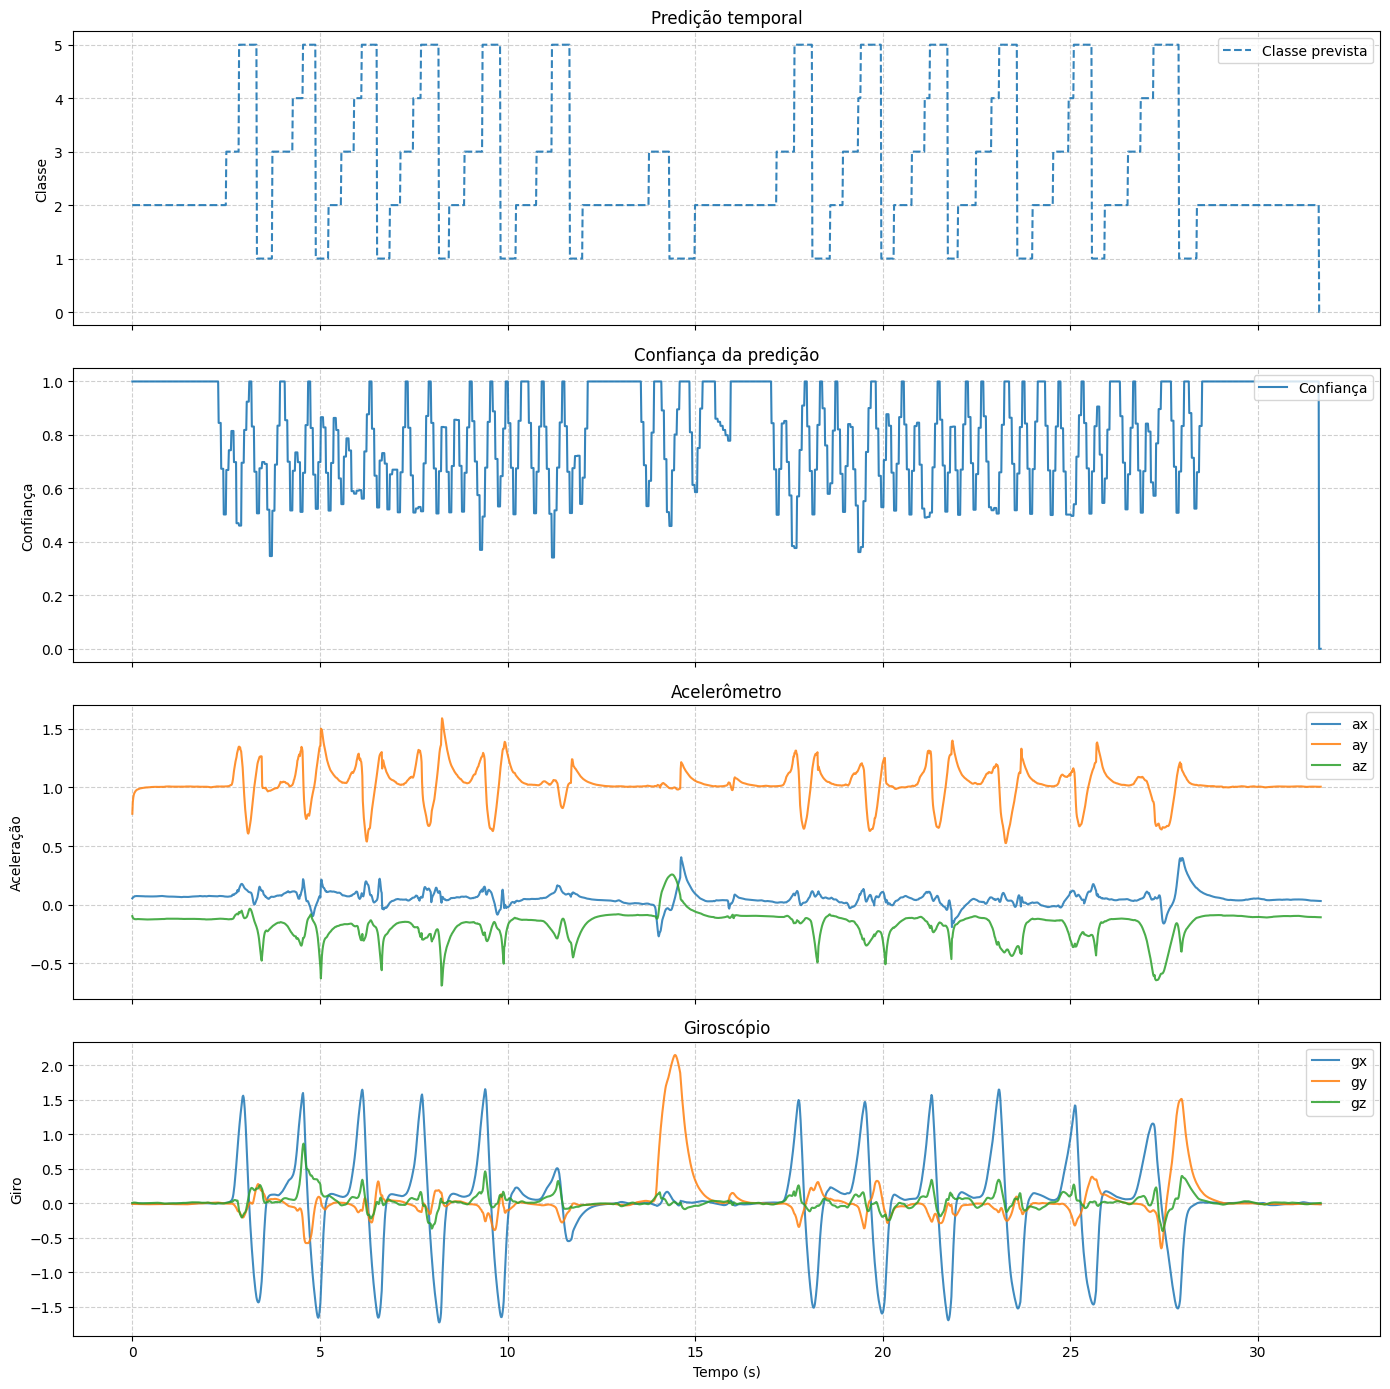

,timestamp,ax,ay,az,gx,gy,gz,roll,pitch,delay_ms,arquivo_id,arquivo_nome,Fase,tem_rotulo_real,tempo_s,pitch_k,acc_norm,gyro_norm,d_ax,dd_ax,d_ay,dd_ay,d_az,dd_az,d_gx,dd_gx,d_gy,dd_gy,d_gz,dd_gz,d_roll,dd_roll,d_pitch_k,dd_pitch_k,d_acc_norm,dd_acc_norm,d_gyro_norm,dd_gyro_norm,jerk_acc,jerk_gyro,classe_prevista,classe_prevista_nome,confianca_prevista
0,1777327335993,0.053535,0.775419,-0.098242,0.000294,-0.006813,0.007459,88.462043,0,3.27924,999,alog_newF11.csv,0,False,0.000,-3.565256,0.783449,0.010107,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2,Foot-flat,1.0
1,1777327336006,0.059784,0.875443,-0.111928,-0.000999,-0.007404,0.010164,92.895729,0,3.26645,999,alog_newF11.csv,0,False,0.013,-3.721013,0.884592,0.012614,0.006249,0.006249,0.100024,0.100024,-0.013686,-0.013686,-0.001293,-0.001293,-0.000591,-0.000591,0.002705,0.002705,4.433686,4.433686,-0.155757,-0.155757,0.101143,0.101143,0.002508,0.002508,0.101143,0.002508,2,Foot-flat,1.0
2,1777327336020,0.062997,0.915989,-0.116886,-0.001230,-0.007684,0.011488,94.541040,0,3.27956,999,alog_newF11.csv,0,False,0.027,-3.789354,0.925563,0.013876,0.003213,-0.003036,0.040546,-0.059478,-0.004958,0.008728,-0.000231,0.001062,-0.000280,0.000311,0.001324,-0.001380,1.645311,-2.788375,-0.068341,0.087416,0.040971,-0.060172,0.001261,-0.001246,0.040971,0.001261,2,Foot-flat,1.0
3,1777327336033,0.066104,0.938387,-0.119663,-0.001516,-0.007564,0.012505,95.420137,0,3.27778,999,alog_newF11.csv,0,False,0.040,-3.856387,0.948293,0.014693,0.003106,-0.000107,0.022398,-0.018148,-0.002777,0.002181,-0.000286,-0.000055,0.000120,0.000400,0.001017,-0.000308,0.879097,-0.766213,-0.067032,0.001309,0.022730,-0.018242,0.000818,-0.000444,0.022730,0.000818,2,Foot-flat,1.0
4,1777327336046,0.070214,0.950748,-0.122483,-0.001651,-0.008034,0.012287,95.990595,0,3.26996,999,alog_newF11.csv,0,False,0.053,-3.955229,0.961173,0.014773,0.004110,0.001004,0.012361,-0.010037,-0.002820,-0.000043,-0.000135,0.000151,-0.000470,-0.000590,-0.000218,-0.001235,0.570458,-0.308639,-0.098842,-0.031810,0.012880,-0.009849,0.000080,-0.000738,0.012880,0.000080,2,Foot-flat,1.0


In [ ]:
resultado_uso = run_inference_on_file(
    plot_file=PLOT_FILE,
    artefato=artefato,
    save_csv=SALVAR_CSV_COM_PREDICAO,
    show_plots=MOSTRAR_PLOTS,
    evaluate_if_labeled=AVALIAR_SE_O_ARQUIVO_TIVER_ROTULO,
)

display(resultado_uso["df_plot"].head())

## 9) Exportar modelo final para C/C++ `.h`

Esta seção gera um arquivo `.h` parecido com o `modelx_F11.h`.

Ela exporta o **classificador principal XGBoost** para uma classe C++ com método:

```cpp
int predict(const float *x);
```

onde `x` é o vetor de features já calculado na mesma ordem usada no treino.

> Importante: o header não lê CSV e não calcula sozinho as features brutas de acelerômetro/giroscópio. Ele espera receber o vetor final de features. Por isso, esta seção também salva um arquivo `*_features.json` com a ordem exata das features.


In [ ]:
# =========================
# EXPORTAÇÃO PARA C/C++ HEADER
# =========================

EXPORTAR_HEADER_CPP = True

# Caminho de saída do header.
# No Colab, você pode salvar direto no Drive.
HEADER_EXPORT_PATH = ARTIFACT_PATH.replace(".joblib", "_model.h").replace(".pkl", "_model.h")

# Manifesto com a ordem das features esperadas por predict(float *x)
FEATURE_MANIFEST_PATH = HEADER_EXPORT_PATH.replace(".h", "_features.json")

# Nome da classe C++ gerada
CPP_CLASS_NAME = "GaitXGB"

# Exportar apenas até best_iteration deixa o header menor e mais próximo do modelo usado pelo XGBoost.
USAR_BEST_ITERATION_NO_HEADER = True

# Se a melhor configuração tiver bias de probabilidade, ele pode ser convertido em bias nos logits.
# Para V5.3 normalmente o best_cfg é raw, então isso não altera nada.
APLICAR_BIAS_CALIBRADO_NO_HEADER = True


In [ ]:
import re
from datetime import datetime

def build_feature_names_for_manifest():
    per_signal_stats = [
        "mean", "std", "median", "min", "max",
        "p10", "p25", "p75", "p90",
        "first", "last", "delta",
        "center_mean",
        "mean_abs_diff", "std_diff",
        "rms", "energy", "amp",
        "argmax_abs_ratio", "argmin_ratio",
        "zero_cross",
        "center_diff_mean",
        "fft_dom_bin", "fft_dom_ratio", "fft_entropy",
    ]

    names = []

    for axis in AXES:
        for stat in per_signal_stats:
            names.append(f"{axis}__{stat}")

    for a, b in PAIRWISE_CORR_COLS:
        names.append(f"corr__{a}__{b}")

    for axis in HALF_COMPARISON_AXES:
        names.append(f"{axis}__half_mean_diff")
        names.append(f"{axis}__half_std_diff")
        names.append(f"{axis}__half_mean_ratio")

    for axis in TRANSITION_FOCUS_AXES:
        names.append(f"{axis}__center_slope")
        names.append(f"{axis}__peak_position_ratio")
        names.append(f"{axis}__time_since_last_peak_ratio")
        names.append(f"{axis}__half_ratio")

    names.append("pitch_k__local_amplitude")
    names.append("roll__local_amplitude")
    names.append("gz__peak_position_ratio_abs")
    names.append("gz__center_slope")
    names.append("gz__local_amplitude")

    return names

def _c_float(value):
    value = float(value)
    if not np.isfinite(value):
        raise ValueError(f"Valor não finito encontrado no modelo: {value}")
    s = f"{value:.9g}"
    if ("." not in s) and ("e" not in s) and ("E" not in s):
        s += ".0"
    return s + "f"

def _sanitize_cpp_identifier(name):
    name = re.sub(r"[^a-zA-Z0-9_]", "_", str(name))
    if not name or name[0].isdigit():
        name = "_" + name
    return name

def _parse_xgb_feature_index(split_name):
    # XGBoost normalmente usa f0, f1, ...
    m = re.fullmatch(r"f(\d+)", str(split_name))
    if m:
        return int(m.group(1))
    raise ValueError(
        f"Split '{split_name}' não está no formato f0/f1/... "
        "Exporte o modelo treinado com numpy array, não DataFrame nomeado, ou adapte o parser."
    )

def _node_by_id(children):
    return {int(child["nodeid"]): child for child in children}

def _xgb_tree_node_to_cpp(node, indent="        "):
    if "leaf" in node:
        return indent + "return " + _c_float(node["leaf"]) + ";\n"

    fid = _parse_xgb_feature_index(node["split"])
    threshold = _c_float(node["split_condition"])

    children = _node_by_id(node["children"])
    yes_node = children[int(node["yes"])]
    no_node = children[int(node["no"])]
    missing_id = int(node.get("missing", node["yes"]))

    code = ""
    # XGBoost usa condição x[f] < split_condition.
    if missing_id == int(node["yes"]):
        code += indent + f"if (isnan(x[{fid}]) || x[{fid}] < {threshold}) {{\n"
        code += _xgb_tree_node_to_cpp(yes_node, indent + "    ")
        code += indent + "} else {\n"
        code += _xgb_tree_node_to_cpp(no_node, indent + "    ")
        code += indent + "}\n"
    elif missing_id == int(node["no"]):
        code += indent + f"if (isnan(x[{fid}]) || !(x[{fid}] < {threshold})) {{\n"
        code += _xgb_tree_node_to_cpp(no_node, indent + "    ")
        code += indent + "} else {\n"
        code += _xgb_tree_node_to_cpp(yes_node, indent + "    ")
        code += indent + "}\n"
    else:
        missing_node = children[missing_id]
        code += indent + f"if (isnan(x[{fid}])) {{\n"
        code += _xgb_tree_node_to_cpp(missing_node, indent + "    ")
        code += indent + f"}} else if (x[{fid}] < {threshold}) {{\n"
        code += _xgb_tree_node_to_cpp(yes_node, indent + "    ")
        code += indent + "} else {\n"
        code += _xgb_tree_node_to_cpp(no_node, indent + "    ")
        code += indent + "}\n"

    return code

def _eval_xgb_tree_python(node, x):
    if "leaf" in node:
        return float(node["leaf"])

    fid = _parse_xgb_feature_index(node["split"])
    thr = float(node["split_condition"])
    children = _node_by_id(node["children"])

    val = float(x[fid])
    if np.isnan(val):
        next_id = int(node.get("missing", node["yes"]))
    elif val < thr:
        next_id = int(node["yes"])
    else:
        next_id = int(node["no"])

    return _eval_xgb_tree_python(children[next_id], x)

def _get_xgb_tree_dump_limited(model, num_class, use_best_iteration=True):
    booster = model.get_booster()
    dumps = booster.get_dump(dump_format="json")

    best_iteration = getattr(model, "best_iteration", None)
    if best_iteration is None:
        try:
            best_iteration = int(booster.attr("best_iteration"))
        except Exception:
            best_iteration = None

    if use_best_iteration and best_iteration is not None:
        n_trees = min(len(dumps), (int(best_iteration) + 1) * int(num_class))
    else:
        n_trees = len(dumps)

    return dumps[:n_trees], best_iteration

def _margin_bias_from_best_cfg(artefato, class_labels, apply_bias=True):
    bias = np.zeros(len(class_labels), dtype=float)

    if not apply_bias:
        return bias

    best_cfg = artefato.get("best_cfg", {})
    if best_cfg.get("variant", "raw") != "calibrated":
        return bias

    cfg_bias = {
        2: float(best_cfg.get("bias2", 1.0)),
        3: float(best_cfg.get("bias3", 1.0)),
        4: float(best_cfg.get("bias4", 1.0)),
    }

    for classe, b in cfg_bias.items():
        if classe in class_labels and b > 0:
            bias[class_labels.index(classe)] += float(np.log(b))

    return bias

def predict_from_xgb_dump_python(model, X, class_labels, artefato=None, use_best_iteration=True, apply_bias=True):
    class_labels = list(map(int, class_labels))
    num_class = len(class_labels)
    dumps, _ = _get_xgb_tree_dump_limited(model, num_class, use_best_iteration=use_best_iteration)
    trees = [json.loads(d) for d in dumps]
    margin_bias = np.zeros(num_class, dtype=float)
    if artefato is not None:
        margin_bias = _margin_bias_from_best_cfg(artefato, class_labels, apply_bias=apply_bias)

    preds = []
    for row in np.asarray(X, dtype=float):
        votes = margin_bias.astype(float).copy()
        for i, tree in enumerate(trees):
            votes[i % num_class] += _eval_xgb_tree_python(tree, row)
        preds.append(class_labels[int(np.argmax(votes))])
    return np.array(preds, dtype=int)

def export_xgb_classifier_to_eloquent_header(
    artefato,
    header_path,
    class_name="GaitXGB",
    manifest_path=None,
    use_best_iteration=True,
    apply_calibrated_bias=True,
):
    model = artefato["model_main"]
    le = artefato["label_encoder_known"]

    class_labels = [int(v) for v in list(le.classes_)]
    num_class = len(class_labels)

    feature_names = build_feature_names_for_manifest()
    n_features = int(getattr(model, "n_features_in_", len(feature_names)))

    if len(feature_names) != n_features:
        print(
            f"Atenção: manifest tem {len(feature_names)} features, "
            f"mas o modelo espera {n_features}. Vou salvar mesmo assim."
        )

    dumps, best_iteration = _get_xgb_tree_dump_limited(
        model,
        num_class=num_class,
        use_best_iteration=use_best_iteration,
    )
    trees = [json.loads(d) for d in dumps]
    n_rounds = int(len(trees) / num_class) if num_class > 0 else 0
    margin_bias = _margin_bias_from_best_cfg(
        artefato,
        class_labels,
        apply_bias=apply_calibrated_bias,
    )

    class_name = _sanitize_cpp_identifier(class_name)
    guard = f"{class_name.upper()}_MODEL_H"

    lines = []
    lines.append(f"#ifndef {guard}\n")
    lines.append(f"#define {guard}\n\n")
    lines.append("#pragma once\n")
    lines.append("#include <stdint.h>\n")
    lines.append("#include <math.h>\n\n")
    lines.append("// Arquivo gerado automaticamente pelo notebook Gait RF/XGBoost.\n")
    lines.append(f"// Data de geração: {datetime.now().isoformat(timespec='seconds')}\n")
    lines.append(f"// Classes originais: {class_labels}\n")
    lines.append(f"// Número de features esperado: {n_features}\n")
    lines.append(f"// Número de árvores exportadas: {len(trees)}\n")
    lines.append(f"// Rodadas exportadas: {n_rounds}\n")
    lines.append(f"// best_iteration Python/XGBoost: {best_iteration}\n\n")

    lines.append("namespace Eloquent {\n")
    lines.append("    namespace ML {\n")
    lines.append("        namespace Port {\n")
    lines.append(f"            class {class_name} {{\n")
    lines.append("                public:\n")
    lines.append(f"                    static const uint16_t NUM_FEATURES = {n_features};\n")
    lines.append(f"                    static const uint8_t NUM_CLASSES = {num_class};\n\n")

    lines.append("                    int predict(float *x) {\n")
    lines.append("                        return predict((const float*) x);\n")
    lines.append("                    }\n\n")

    lines.append("                    int predict(const float *x) {\n")
    lines.append("                        uint8_t classIdx = predictIndex(x);\n")
    labels_str = ", ".join(str(v) for v in class_labels)
    lines.append(f"                        const int classLabels[{num_class}] = {{ {labels_str} }};\n")
    lines.append("                        return classLabels[classIdx];\n")
    lines.append("                    }\n\n")

    lines.append("                    uint8_t predictIndex(const float *x) {\n")
    bias_init = ", ".join(_c_float(v) for v in margin_bias)
    lines.append(f"                        float votes[{num_class}] = {{ {bias_init} }};\n\n")
    for tree_idx in range(len(trees)):
        cls_idx = tree_idx % num_class
        lines.append(f"                        votes[{cls_idx}] += tree_{tree_idx}(x);\n")
    lines.append("\n")
    lines.append("                        uint8_t classIdx = 0;\n")
    lines.append("                        float maxVote = votes[0];\n")
    lines.append(f"                        for (uint8_t i = 1; i < {num_class}; i++) {{\n")
    lines.append("                            if (votes[i] > maxVote) {\n")
    lines.append("                                classIdx = i;\n")
    lines.append("                                maxVote = votes[i];\n")
    lines.append("                            }\n")
    lines.append("                        }\n")
    lines.append("                        return classIdx;\n")
    lines.append("                    }\n\n")

    lines.append("                protected:\n")
    for tree_idx, tree in enumerate(trees):
        lines.append(f"                    float tree_{tree_idx}(const float *x) const {{\n")
        lines.append(_xgb_tree_node_to_cpp(tree, indent="                        "))
        lines.append("                    }\n\n")

    lines.append("            };\n")
    lines.append("        }\n")
    lines.append("    }\n")
    lines.append("}\n\n")
    lines.append(f"#endif // {guard}\n")

    os.makedirs(os.path.dirname(header_path), exist_ok=True)
    with open(header_path, "w", encoding="utf-8") as f:
        f.write("".join(lines))

    manifest = {
        "class_name": class_name,
        "header_path": header_path,
        "num_features_model": n_features,
        "num_features_manifest": len(feature_names),
        "num_classes": num_class,
        "class_labels": class_labels,
        "window_size": int(artefato.get("window_size", WINDOW_SIZE)),
        "step": int(artefato.get("step", STEP)),
        "best_iteration": None if best_iteration is None else int(best_iteration),
        "num_trees_exported": int(len(trees)),
        "num_rounds_exported": int(n_rounds),
        "feature_version": artefato.get("feature_version", None),
        "best_cfg": artefato.get("best_cfg", None),
        "note": "O header espera um vetor float x[] com as features nesta ordem.",
        "feature_names": feature_names,
    }

    if manifest_path is not None:
        os.makedirs(os.path.dirname(manifest_path), exist_ok=True)
        with open(manifest_path, "w", encoding="utf-8") as f:
            json.dump(manifest, f, ensure_ascii=False, indent=2)

    return manifest

def verificar_export_xgb_em_python(artefato, n_amostras=100):
    """Compara a lógica do dump XGBoost com o predict_proba do Python usando o PLOT_FILE."""
    try:
        df_tmp = prepare_file_for_inference(PLOT_FILE)
        X_tmp, _ = create_windows_inference(df_tmp, WINDOW_SIZE, STEP, PLOT_FILE)
        if len(X_tmp) == 0:
            print("Não há janelas suficientes para verificar o export.")
            return None

        X_check = X_tmp[:min(n_amostras, len(X_tmp))]
        model = artefato["model_main"]
        le = artefato["label_encoder_known"]
        class_labels = [int(v) for v in list(le.classes_)]

        pred_python = le.inverse_transform(np.argmax(model.predict_proba(X_check), axis=1))
        pred_dump = predict_from_xgb_dump_python(
            model,
            X_check,
            class_labels=class_labels,
            artefato=artefato,
            use_best_iteration=USAR_BEST_ITERATION_NO_HEADER,
            apply_bias=False,  # compara o modelo bruto com predict_proba bruto
        )

        acc = float(np.mean(pred_python.astype(int) == pred_dump.astype(int)))
        print(f"Verificação Python dump vs XGBoost em {len(X_check)} janelas: {acc:.4f}")

        if acc < 0.99:
            print("Atenção: houve divergência entre o dump e o modelo Python. Revise antes de embarcar.")
        return acc
    except Exception as e:
        print("Não foi possível verificar automaticamente o export:", repr(e))
        return None


In [ ]:
if EXPORTAR_HEADER_CPP:
    manifest = export_xgb_classifier_to_eloquent_header(
        artefato=artefato,
        header_path=HEADER_EXPORT_PATH,
        class_name=CPP_CLASS_NAME,
        manifest_path=FEATURE_MANIFEST_PATH,
        use_best_iteration=USAR_BEST_ITERATION_NO_HEADER,
        apply_calibrated_bias=APLICAR_BIAS_CALIBRADO_NO_HEADER,
    )

    print("Header exportado em:", HEADER_EXPORT_PATH)
    print("Manifesto de features exportado em:", FEATURE_MANIFEST_PATH)
    print("Resumo:")
    print(json.dumps({
        "num_features": manifest["num_features_model"],
        "num_classes": manifest["num_classes"],
        "class_labels": manifest["class_labels"],
        "best_iteration": manifest["best_iteration"],
        "num_trees_exported": manifest["num_trees_exported"],
        "num_rounds_exported": manifest["num_rounds_exported"],
    }, indent=2, ensure_ascii=False))

    _ = verificar_export_xgb_em_python(artefato, n_amostras=100)
else:
    print("Exportação desativada. Coloque EXPORTAR_HEADER_CPP = True para gerar o .h.")


Header exportado em: /content/drive/MyDrive/modelos/gait_xgb_v5_3_min_model.h
Manifesto de features exportado em: /content/drive/MyDrive/modelos/gait_xgb_v5_3_min_model_features.json
Resumo:
{
  "num_features": 647,
  "num_classes": 5,
  "class_labels": [
    1,
    2,
    3,
    4,
    5
  ],
  "best_iteration": 182,
  "num_trees_exported": 915,
  "num_rounds_exported": 183
}
Verificação Python dump vs XGBoost em 100 janelas: 0.9900


## 10) Como usar o `.h` no Arduino/ESP32

Exemplo mínimo:

```cpp
#include "gait_xgb_v5_3_model.h"

Eloquent::ML::Port::GaitXGB model;

void loop() {
    float x[Eloquent::ML::Port::GaitXGB::NUM_FEATURES];

    // Preencha x[] com as features calculadas na MESMA ordem do arquivo *_features.json.
    // x[0] = primeira feature
    // x[1] = segunda feature
    // ...

    int classe = model.predict(x);
}
```

Pontos importantes:

1. O `.h` **não recebe ax, ay, az, gx, gy, gz crus diretamente**.  
   Ele recebe o vetor final de features.

2. O arquivo `*_features.json` diz a ordem exata das features.

3. Se o objetivo for rodar tudo no microcontrolador, o próximo passo é portar também a extração de features para C/C++.

4. Para começar mais fácil, dá para calcular as features em Python, enviar `x[]` para o dispositivo e testar se o `.h` responde igual.
